# 2. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                             f1_score, precision_score, recall_score)
import time
from sklearn.base import clone
from sklearn.metrics import cohen_kappa_score
from sklearn.pipeline import Pipeline

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# 3. Data Loading Function & Config

In [14]:
def load_data(name):
    data_path = os.path.join("..", "data")
    files = {
        "IP": ("Indian_pines.mat", "indian_pines_corrected", "Indian_pines_gt.mat", "indian_pines_gt"),
        "PU": ("PaviaU.mat", "paviaU", "PaviaU_gt.mat", "paviaU_gt"),
        "SA": ("Salinas.mat", "salinas", "Salinas_gt.mat", "salinas_gt"),
    }
    df, dk, gf, gk = files[name]
    data = sio.loadmat(os.path.join(data_path, df))[dk]
    labels = sio.loadmat(os.path.join(data_path, gf))[gk]
    return data, labels

dataset    = 'SA'    # 'IP', 'PU', or 'SA'
 

X, y = load_data(dataset)
print(f'Data shape: {X.shape}, GT shape: {y.shape}')

Data shape: (512, 217, 224), GT shape: (512, 217)


In [3]:
random_state = 42
train_ratio = 0.7

# Convert Grayscle by PCA 1 component 

In [15]:
newX = np.reshape(X, (-1, X.shape[2]))
pca = PCA(n_components=1, random_state=random_state)
newX = pca.fit_transform(newX)
scaler = MinMaxScaler().fit(newX)
newX = scaler.transform(newX)
X_pca = np.reshape(newX, (X.shape[0], X.shape[1], 1))
X_pca.shape

(512, 217, 1)

# Pach window

In [16]:
def padWithZeros(X, margin=2):
    newX = np.zeros((X.shape[0] + 2*margin, X.shape[1] + 2*margin, X.shape[2]))
    newX[margin:X.shape[0]+margin, margin:X.shape[1]+margin, :] = X
    return newX

def createImageCubes(X, y, windowSize=25, removeZeroLabels=True):
    margin = int((windowSize - 1) / 2)
    zeroPaddedX = padWithZeros(X, margin=margin)
    patchesData = np.zeros((X.shape[0]*X.shape[1], windowSize, windowSize, X.shape[2]))
    patchesLabels = np.zeros((X.shape[0]*X.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0]-margin):
        for c in range(margin, zeroPaddedX.shape[1]-margin):
            patch = zeroPaddedX[r-margin:r+margin+1, c-margin:c+margin+1]
            patchesData[patchIndex] = patch
            patchesLabels[patchIndex] = y[r-margin, c-margin]
            patchIndex += 1
    if removeZeroLabels:
        patchesData = patchesData[patchesLabels > 0]
        patchesLabels = patchesLabels[patchesLabels > 0]
        patchesLabels -= 1
    return patchesData, patchesLabels


X_patches, y_patches = createImageCubes(X_pca, y, windowSize=25, removeZeroLabels=True)
X_patches =   X_patches.reshape(X_patches.shape[0], -1)
X_patches.shape

(54129, 625)

# Evaluate by extratree

In [17]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    classes = np.unique(y_true)
    aa = np.mean([accuracy_score(y_true[y_true == c], y_pred[y_true == c]) for c in classes]) * 100
    return {
        'OA': round(accuracy_score(y_true, y_pred) * 100, 4),
        'AA': round(aa, 4),
        'Kappa': round(cohen_kappa_score(y_true, y_pred) * 100, 4),
        'F1': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 6),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 6),
        'Recall': round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 6),
    }

In [18]:
clf = ExtraTreesClassifier(n_estimators=100, random_state=random_state)
cv_clf = clone(clf)
X_train, X_test, y_train, y_test = train_test_split(X_patches, y_patches, test_size=train_ratio, random_state=random_state, stratify=y_patches)

start_train = time.time()
clf.fit(X_train, y_train)
train_time = time.time() - start_train

start_test = time.time()
y_pred = clf.predict(X_test)
test_time = time.time() - start_test

metrics = compute_metrics(y_test, y_pred)
print(f"Train Time: {train_time:.2f}s Test Time: {test_time:.2f}s")
for key, val in metrics.items():
    print(f"{key} = {val:.2f}%")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',cv_clf),
])
cross_score = cross_val_score(
    pipe, X_patches, y_patches,
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
) 
print(f"CV = {cross_score.mean()*100:.2f}% OA = {metrics['OA']:.2f}%, AA = {metrics['AA']:.2f}%, Kappa = {metrics['Kappa']:.4f}")


Train Time: 12.34s Test Time: 1.51s
OA = 97.84%
AA = 99.15%
Kappa = 97.59%
F1 = 0.98%
Precision = 0.98%
Recall = 0.98%
CV = 99.23% OA = 97.84%, AA = 99.15%, Kappa = 97.5901


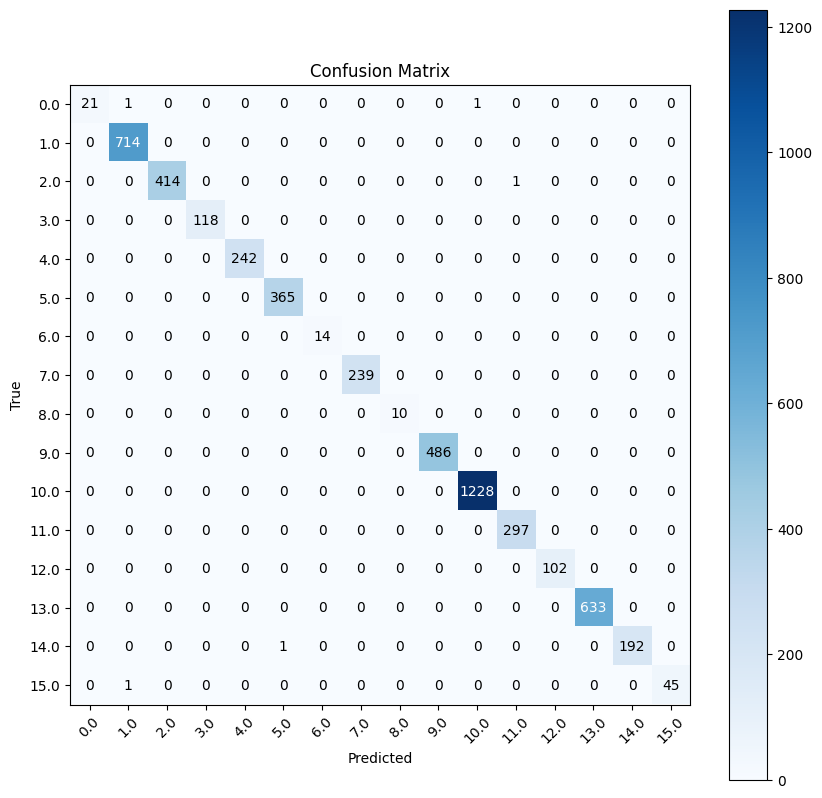

              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95        23
         1.0       1.00      1.00      1.00       714
         2.0       1.00      1.00      1.00       415
         3.0       1.00      1.00      1.00       118
         4.0       1.00      1.00      1.00       242
         5.0       1.00      1.00      1.00       365
         6.0       1.00      1.00      1.00        14
         7.0       1.00      1.00      1.00       239
         8.0       1.00      1.00      1.00        10
         9.0       1.00      1.00      1.00       486
        10.0       1.00      1.00      1.00      1228
        11.0       1.00      1.00      1.00       297
        12.0       1.00      1.00      1.00       102
        13.0       1.00      1.00      1.00       633
        14.0       1.00      0.99      1.00       193
        15.0       1.00      0.98      0.99        46

    accuracy                           1.00      5125
   macro avg       1.00   

In [73]:
#plot confusion matrix
classes = np.unique(y_test)
plt.figure(figsize=(10, 10))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
 
plt.show()
#plot classification report
cr = classification_report(y_test, y_pred)
print(cr)
